# Ottawa Neighbourhood Safety — Cluster Analysis

This notebook analyses the safety clusters produced by the Model Building notebook. Each analysis builds on the cluster labels to answer a progressively deeper question about Ottawa's neighbourhood safety landscape — from where crime concentrates geographically, to what type of crime defines each cluster, to which individual neighbourhoods are closest to tipping into a higher-risk group.

---

## Input

`ClusteredData.csv` — 104 neighbourhoods × 25 columns (all cleaned features + `cluster` label). Produced by the Model Building notebook.

---

## Analyses
1. Geospatial Map
2. Crime Type Composition per Cluster
3. Police Demand vs. Crime Level
4. Feature Z-Score Heatmap
5. Silhouette Score per Neighbourhood


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

import geopandas as gpd
import matplotlib.pyplot as plt

import folium
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples
import matplotlib.patches as mpatches


ModuleNotFoundError: No module named 'geopandas'

In [2]:
# Importing the dataset
df = pd.read_csv('data/processed/Clustered_Data.csv')
df.head(3)

,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium,geometry,cluster
0,Barrhaven,3,208,0,79,258,10,171,0,59,346,9,3,4,103.0,61.0,0.0,3.0,0.0,2.0,563.0,39166,185,2592,5100,"POLYGON ((-75.7742283499069 45.2610220238087, ...",0
1,Bayshore,3,278,1,129,244,6,203,11,73,1722,42,0,5,119.0,90.0,0.0,0.0,0.0,8.0,667.0,9313,80,1089,2501,"POLYGON ((-75.802358463964 45.3572739626829, -...",0
2,Beacon Hill South - Cardinal Heights,5,266,1,107,210,9,187,4,76,598,23,0,9,76.0,60.0,0.0,0.0,0.0,3.0,565.0,7195,75,1037,2141,"POLYGON ((-75.5854310351397 45.4488709131604, ...",8


In [4]:
df.describe()

,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium,cluster
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,8.375000,299.365385,0.778846,192.355769,250.403846,15.250000,196.509615,9.519231,66.048077,1126.086538,30.403846,1.173077,6.721154,104.048077,148.269231,0.067308,0.682692,0.432692,4.673077,890.826923,8736.307692,130.538462,1686.173077,3094.769231,4.980769
std,11.341296,436.868980,1.328966,293.022711,305.825178,32.383248,252.201106,15.552592,83.030861,1877.768652,34.253061,1.866632,11.312384,101.837047,341.449601,0.287757,1.286709,0.973079,6.034597,2694.562023,7409.850223,212.825053,2364.289616,4310.534376,3.355855
min,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,17.000000,0.000000,9.000000,19.000000,0.000000
25%,2.000000,74.750000,0.000000,54.500000,86.750000,2.000000,63.750000,2.000000,19.000000,153.000000,11.000000,0.000000,1.000000,44.750000,13.500000,0.000000,0.000000,0.000000,1.000000,230.000000,4245.000000,42.500000,563.750000,949.250000,1.000000
50%,5.000000,162.500000,0.000000,99.500000,158.000000,6.000000,116.000000,5.000000,43.500000,360.500000,18.500000,0.000000,3.000000,78.000000,44.500000,0.000000,0.000000,0.000000,2.000000,400.500000,6805.500000,61.500000,894.000000,1517.500000,7.000000
75%,9.250000,338.250000,1.000000,207.000000,294.500000,10.000000,238.250000,9.250000,76.000000,1433.500000,35.000000,1.250000,8.250000,129.500000,110.000000,0.000000,1.000000,0.000000,5.250000,810.250000,10701.000000,138.250000,1990.000000,3992.500000,8.000000
max,67.000000,2790.000000,6.000000,2452.000000,2273.000000,205.000000,1983.000000,97.000000,660.000000,11565.000000,236.000000,10.000000,98.000000,605.000000,2437.000000,2.000000,6.000000,5.000000,28.000000,27304.000000,46263.000000,1317.000000,18859.000000,28926.000000,8.000000


### 1. Geospatial Map
Plots each neighbourhood polygon on an interactive Google Maps base layer, coloured by cluster on a six-step green-to-dark-maroon gradient (safest → highest crime). Clusters are ranked by average total crime per neighbourhood before colour is assigned, so the gradient is always meaningful regardless of cluster numbering. Saved to `ottawa_cluster_map.html`.
- **Tooltip**: neighbourhood name, cluster, population
- **Popup**: homicide, shootings, auto theft counts

In [8]:
# geometry column is WKT from CSV — parse it into a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.GeoSeries.from_wkt(df['geometry']),
    crs='EPSG:4326'
)

# rank clusters by mean total crime (lowest = safest = green)
non_crime_cols = {'Neighbourhood', 'cluster', 'Population',
                  'Police_Critical', 'Police_High', 'Police_Medium', 'geometry'}
crime_cols = [c for c in gdf.columns if c not in non_crime_cols]

cluster_crime_rank = (
    gdf.assign(total_crime=gdf[crime_cols].sum(axis=1))
       .groupby('cluster')['total_crime']
       .mean()
       .sort_values()
       .index.tolist()
)

# green → yellow-green → yellow → orange → red → dark maroon gradient,
# sampled to fit however many clusters exist (safe for sub-clustered dataframes)
import matplotlib.colors as mcolors

n_clusters = len(cluster_crime_rank)
gradient = mcolors.LinearSegmentedColormap.from_list(
    'crime_gradient', ['#006837', '#78c679', '#ffffb2', '#fd8d3c', '#f03b20', '#67000d']
)
palette   = [mcolors.to_hex(gradient(i / max(n_clusters - 1, 1))) for i in range(n_clusters)]
color_map = {cid: palette[i] for i, cid in enumerate(cluster_crime_rank)}

# Google Maps tile (roads + POIs)
m = folium.Map(
    location=[45.4215, -75.6972],
    zoom_start=11,
    tiles='http://mt0.google.com/vt/lyrs=m&hl=en&x={x}&y={y}&z={z}',
    attr='Google Maps'
)

folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda feat: {
        'fillColor':   color_map.get(feat['properties']['cluster'], '#cccccc'),
        'color':       'white',
        'weight':      1,
        'fillOpacity': 0.70,
    },
    tooltip=folium.GeoJsonTooltip(
        fields   =['Neighbourhood', 'cluster', 'Population'],
        aliases  =['Neighbourhood', 'Cluster',  'Population'],
        sticky   =True,
        style    ='font-size:13px;'
    ),
    popup=folium.GeoJsonPopup(
        fields =['Neighbourhood', 'cluster', 'Population',
                 'Murder 1st Dgree', 'Murder 2nd Dgree', 'Shootings', 'Auto Theft'],
        aliases=['Neighbourhood', 'Cluster', 'Population',
                 'Murder 1st Dgree', 'Murder 2nd Dgree', 'Shootings', 'Auto Theft'],
    )
).add_to(m)

# legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:12px 16px; border-radius:8px;
            box-shadow:0 2px 6px rgba(0,0,0,0.3); font-family:Arial; font-size:13px;">
  <b>Safety Cluster</b><br>
  <span style="font-size:11px;color:#666;">ranked by avg total crime</span><br><br>
"""
for i, cid in enumerate(cluster_crime_rank):
    rank_label = 'Lowest crime' if i == 0 else ('Highest crime' if i == len(cluster_crime_rank)-1 else '')
    legend_html += (
        f'<i style="background:{color_map[cid]};width:14px;height:14px;'
        f'display:inline-block;margin-right:6px;border-radius:2px;border:1px solid #ccc;"></i>'
        f'Cluster {cid}'
        + (f' <span style="color:#888;font-size:11px;">— {rank_label}</span>' if rank_label else '')
        + '<br>'
    )
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m.save('data/processed/ottawa_cluster_map.html')
m

### 2. Crime Type Composition per Cluster
Breaks each cluster's total incident volume into three categories — **Violent** (assaults, homicide, shootings, sexual violations, and related), **Property** (theft, break & enter, auto/bike theft, mischief, arson), and **Other** — and plots the percentage share as a stacked bar chart sorted safest to highest-crime. Answers: *is a cluster dangerous because of violence, or because of property crime?*

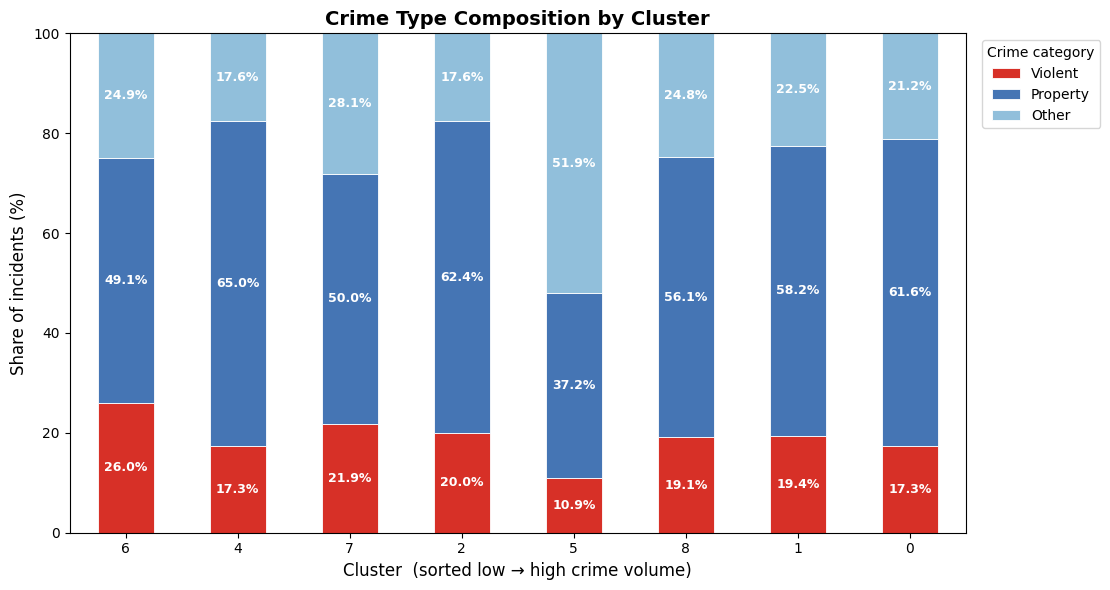

In [9]:
violent_cols  = [
    'Assaults', 'Manslaughter', 'Murder 1st Dgree', 'Murder 2nd Dgree',
    'Shootings', 'Violations Causing Death',
    'Other Violations Involving Violence Or The Threat Of Violence',
    'Sexual Violations', 'Violations Resulting In The Deprivation Of Freedom',
    'Attempting The Commission Of A Capital Crime', 'Offensive Weapons',
]
property_cols = [
    'Theft $5000 and Under', 'Theft Over $5000', 'Break and Enter',
    'Auto Theft', 'Bike Theft', 'Mischief', 'Arson',
    'Possession / Trafficking Stolen Goods',
]
meta_cols = {'Neighbourhood', 'cluster', 'Population',
             'Police_Critical', 'Police_High', 'Police_Medium', 'geometry'}
other_cols = [c for c in df.columns
              if c not in meta_cols and c not in violent_cols and c not in property_cols]

comp = df.copy()
comp['Violent']  = comp[violent_cols].sum(axis=1)
comp['Property'] = comp[property_cols].sum(axis=1)
comp['Other']    = comp[other_cols].sum(axis=1)

# sum per cluster, then convert to row-percentage shares
cluster_comp  = comp.groupby('cluster')[['Violent', 'Property', 'Other']].sum()
cluster_share = cluster_comp.div(cluster_comp.sum(axis=1), axis=0) * 100

# sort clusters by total crime volume (safest → highest)
crime_order   = cluster_comp.sum(axis=1).sort_values().index
cluster_share = cluster_share.loc[crime_order]

# scale figure width to however many clusters exist (was fixed at 10" for 6 clusters)
n_clusters = len(cluster_share)
fig, ax = plt.subplots(figsize=(max(10, n_clusters * 1.4), 6))
cluster_share.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#d73027', '#4575b4', '#91bfdb'],
    edgecolor='white', linewidth=0.6,
)

ax.set_xlabel('Cluster  (sorted low → high crime volume)', fontsize=12)
ax.set_ylabel('Share of incidents (%)', fontsize=12)
ax.set_title('Crime Type Composition by Cluster', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(title='Crime category', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',
                 fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Police Demand vs. Crime Level
Scatter plot of average crime incidents per capita (x) vs. average Police Critical calls per capita (y) for each cluster. An OLS trend line shows the city-wide expected relationship. Points coloured red (above trend = over-serviced) or blue (below trend = under-serviced) reveal where policing levels diverge from what crime volume alone would predict.

*Note: per-capita values are the mean of per-neighbourhood ratios within each cluster, not cluster aggregate ÷ cluster population. Small non-residential areas (cemeteries, industrial zones) inflate the per-capita figure for the rural cluster.*

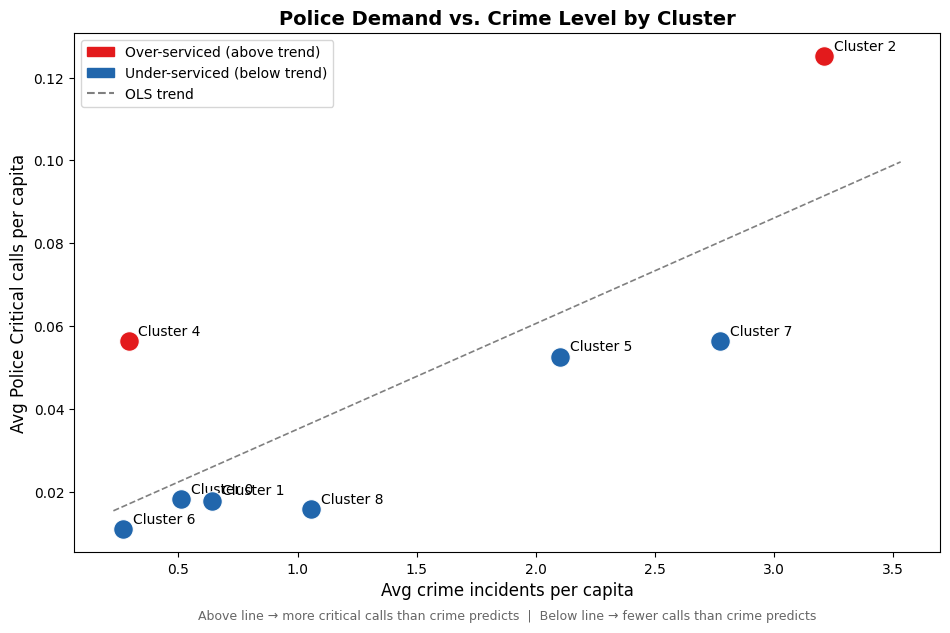

,Avg crime per capita,Avg critical calls per capita
cluster,,
0,0.5123,0.0184
1,0.6420,0.0180
2,3.2120,0.1251
4,0.2906,0.0565
5,2.1031,0.0527
6,0.2665,0.0111
7,2.7762,0.0564
8,1.0570,0.0160


In [11]:
meta_cols = {'Neighbourhood', 'cluster', 'Population',
             'Police_Critical', 'Police_High', 'Police_Medium', 'geometry'}

crime_cols = [c for c in df.columns if c not in meta_cols]

per_cap = df.copy()
per_cap['crime_per_capita']    = per_cap[crime_cols].sum(axis=1) / per_cap['Population']
per_cap['critical_per_capita'] = per_cap['Police_Critical'] / per_cap['Population']

cluster_agg = per_cap.groupby('cluster')[['crime_per_capita', 'critical_per_capita']].mean()

# OLS reference line across all clusters
x = cluster_agg['crime_per_capita'].values
y = cluster_agg['critical_per_capita'].values
m_slope, b_intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min() * 0.85, x.max() * 1.1, 100)

# scale figure to however many clusters exist (was fixed at 9x6 for 6 clusters)
n_clusters = len(cluster_agg)
fig, ax = plt.subplots(figsize=(max(9, n_clusters * 1.2), max(6, n_clusters * 0.8)))

ax.plot(x_line, m_slope * x_line + b_intercept,
        color='grey', linestyle='--', linewidth=1.2, zorder=1)

for cid, row in cluster_agg.iterrows():
    residual = row['critical_per_capita'] - (m_slope * row['crime_per_capita'] + b_intercept)
    color    = '#e31a1c' if residual > 0 else '#2166ac'
    ax.scatter(row['crime_per_capita'], row['critical_per_capita'],
               s=200, color=color, zorder=3, edgecolors='white', linewidths=0.8)
    ax.annotate(f'Cluster {cid}',
                xy=(row['crime_per_capita'], row['critical_per_capita']),
                xytext=(7, 4), textcoords='offset points', fontsize=10)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#e31a1c', label='Over-serviced (above trend)'),
    mpatches.Patch(color='#2166ac', label='Under-serviced (below trend)'),
    plt.Line2D([0], [0], color='grey', linestyle='--', label='OLS trend'),
], fontsize=10)

ax.set_xlabel('Avg crime incidents per capita', fontsize=12)
ax.set_ylabel('Avg Police Critical calls per capita', fontsize=12)
ax.set_title('Police Demand vs. Crime Level by Cluster', fontsize=14, fontweight='bold')
ax.annotate('Above line → more critical calls than crime predicts  |  Below line → fewer calls than crime predicts',
            xy=(0.5, -0.13), xycoords='axes fraction', ha='center', fontsize=9, color='#666')

plt.tight_layout()
plt.show()

cluster_agg.rename(columns={
    'crime_per_capita':    'Avg crime per capita',
    'critical_per_capita': 'Avg critical calls per capita',
}).round(4)

- X axis — avg crime incidents per capita for each cluster
- Y axis — avg Police Critical calls per capita for each cluster
- Dashed OLS line — the city-wide expected relationship between crime and police response
- Red points — clusters above the trend line (receiving more critical calls than their crime level predicts = over-serviced)
- Blue points — clusters below the trend line (fewer calls than predicted = under-serviced)

### 4. Feature Z-Score Heatmap
For each cluster, computes the mean of each crime feature as a z-score relative to the city-wide mean, then plots a cluster × feature heatmap (red = above average, blue = below). Uses 11 key crime dimensions. Answers: *what specifically defines each cluster — which crime types are disproportionately high or low?* Rows are sorted safest to highest-crime for easy visual comparison.

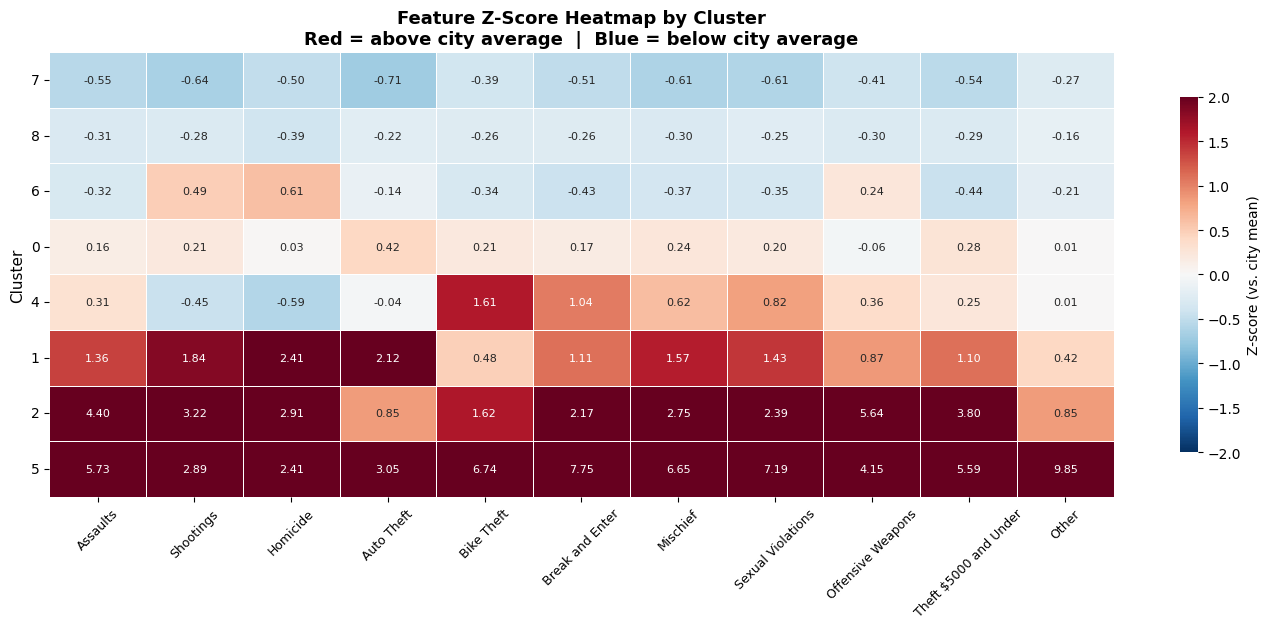

In [15]:
meta_cols  = {'Neighbourhood', 'cluster', 'Population',
              'Police_Critical', 'Police_High', 'Police_Medium', 'geometry'}
crime_cols = [
    'Assaults', 'Shootings', 'Homicide',
    'Auto Theft', 'Bike Theft', 'Break and Enter',
    'Mischief', 'Sexual Violations', 'Offensive Weapons',
    'Theft $5000 and Under', 'Other',
]

# z-score every feature across all neighbourhoods, then average by cluster
z = df.copy()
# 'Homicide' isn't a raw column — the cleaned data splits it into these three
z['Homicide'] = z[['Manslaughter', 'Murder 1st Dgree', 'Murder 2nd Dgree']].sum(axis=1)
z[crime_cols] = z[crime_cols].apply(zscore)
cluster_z     = z.groupby('cluster')[crime_cols].mean()

# sort rows: safest cluster at top → highest-crime cluster at bottom
crime_order = (
    z.assign(total=z[crime_cols].sum(axis=1))
      .groupby('cluster')['total'].mean()
      .sort_values().index
)
cluster_z = cluster_z.loc[crime_order]

# scale heatmap height to however many clusters exist (was fixed at 5" for 6 clusters)
n_clusters = len(cluster_z)
fig, ax = plt.subplots(figsize=(14, max(5, n_clusters * 0.8)))
sns.heatmap(
    cluster_z,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-2, vmax=2,
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Z-score (vs. city mean)', 'shrink': 0.8},
)

ax.set_title(
    'Feature Z-Score Heatmap by Cluster\n'
    'Red = above city average  |  Blue = below city average',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('Cluster', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

### 5. Silhouette Score per Neighbourhood
Computes a silhouette score for every neighbourhood — measuring how well it fits its assigned cluster vs. how close it sits to the nearest neighbouring cluster. Scores range from −1 (misassigned) to +1 (perfectly isolated). Plotted as a horizontal bar chart grouped by cluster.

| Metric | Value |
|--------|-------|
| Overall avg silhouette | 0.186 |
| Best cluster | 3 — 0.381 (rural / low-density, well-separated) |
| Worst cluster | 4 — −0.092 (mixed urban/suburban, internally inconsistent) |
| Most boundary neighbourhood | Ottawa East (Cluster 4) — −0.602 |

Neighbourhoods with scores below zero sit statistically closer to another cluster than their own and warrant individual review.

Overall avg silhouette: 0.108

Per-cluster avg:
 cluster
0   -0.172
1    0.152
2    0.294
4   -0.383
5    0.000
6    0.014
7    0.443
8    0.012


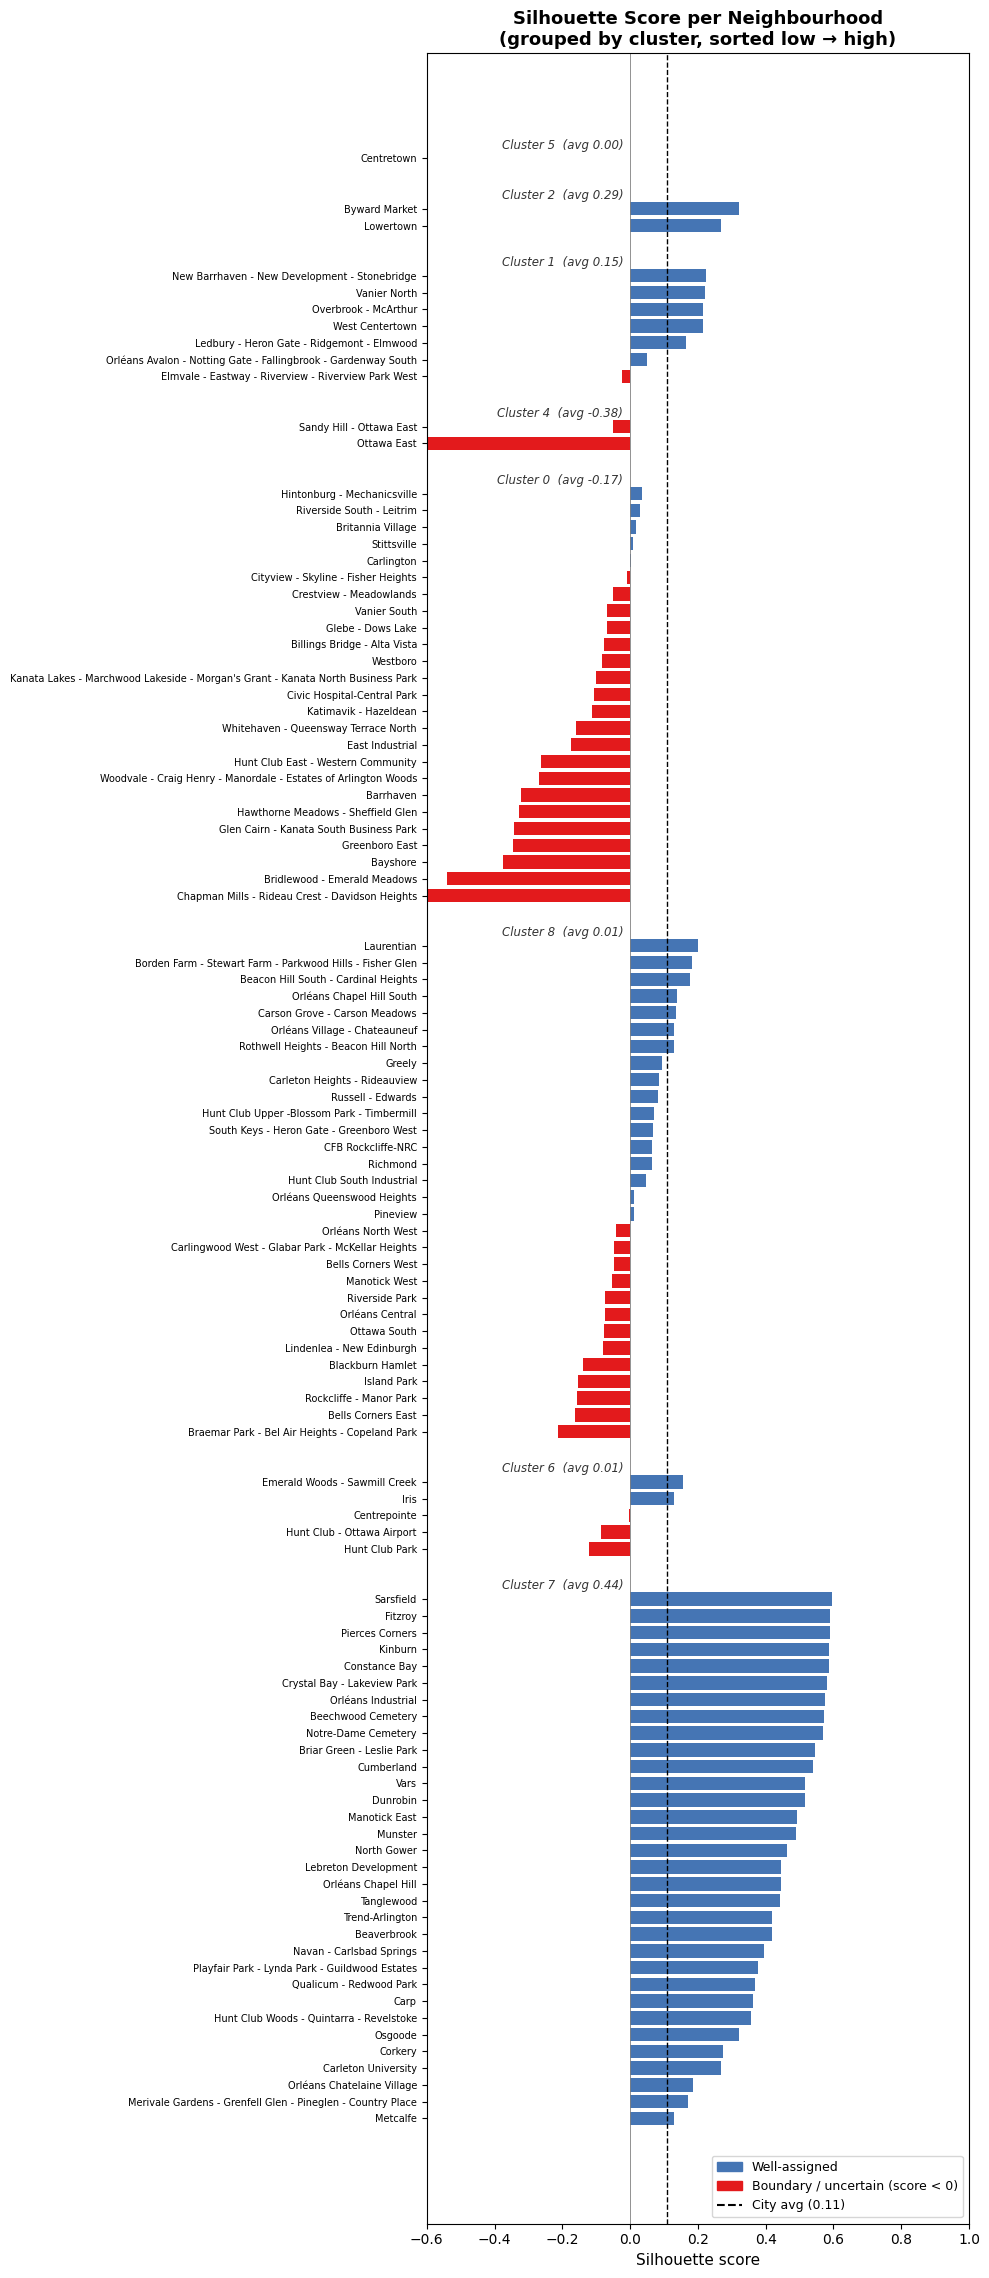


Bottom 10 neighbourhoods by silhouette score:
                                                  Neighbourhood  cluster  silhouette
                                                    Ottawa East        4   -0.714387
                Chapman Mills - Rideau Crest - Davidson Heights        0   -0.606940
                                   Bridlewood - Emerald Meadows        0   -0.539622
                                                       Bayshore        0   -0.376386
                                                 Greenboro East        0   -0.346247
                        Glen Cairn - Kanata South Business Park        0   -0.342426
                             Hawthorne Meadows - Sheffield Glen        0   -0.327944
                                                      Barrhaven        0   -0.321600
Woodvale - Craig Henry - Manordale - Estates of Arlington Woods        0   -0.269765
                             Hunt Club East - Western Community        0   -0.263025


In [16]:
meta_cols  = {'Neighbourhood', 'cluster', 'Population',
              'Police_Critical', 'Police_High', 'Police_Medium', 'geometry'}
crime_cols = [c for c in df.columns if c not in meta_cols]

X      = StandardScaler().fit_transform(df[crime_cols])
labels = df['cluster'].values
scores = silhouette_samples(X, labels)

sil = df[['Neighbourhood', 'cluster']].copy()
sil['silhouette'] = scores

overall_avg = scores.mean()
cluster_avg = sil.groupby('cluster')['silhouette'].mean().round(3)
print(f'Overall avg silhouette: {overall_avg:.3f}')
print('\nPer-cluster avg:\n', cluster_avg.to_string())

# sort clusters by total crime for consistent ordering
crime_order = (
    df.assign(total=df[crime_cols].sum(axis=1))
      .groupby('cluster')['total'].mean()
      .sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, max(8, len(sil) * 0.22)))

y_pos, y_ticks, y_labels, gap = 0, [], [], 2

for cid in crime_order:
    grp = sil[sil['cluster'] == cid].sort_values('silhouette')
    for _, row in grp.iterrows():
        color = '#e31a1c' if row['silhouette'] < 0 else '#4575b4'
        ax.barh(y_pos, row['silhouette'], color=color, edgecolor='none', height=0.8)
        y_ticks.append(y_pos)
        y_labels.append(row['Neighbourhood'])
        y_pos += 1
    ax.text(-0.02, y_pos + gap / 2 - 1.2,
            f'Cluster {cid}  (avg {cluster_avg[cid]:.2f})',
            va='center', ha='right', fontsize=8.5, color='#333', fontstyle='italic')
    y_pos += gap

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='grey', linestyle='-', linewidth=0.6)

ax.legend(handles=[
    mpatches.Patch(color='#4575b4', label='Well-assigned'),
    mpatches.Patch(color='#e31a1c', label='Boundary / uncertain (score < 0)'),
    plt.Line2D([0], [0], color='black', linestyle='--',
               label=f'City avg ({overall_avg:.2f})'),
], fontsize=9, loc='lower right')

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=7)
ax.set_xlabel('Silhouette score', fontsize=11)
ax.set_title('Silhouette Score per Neighbourhood\n(grouped by cluster, sorted low → high)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-0.6, 1.0)
plt.tight_layout()
plt.show()

print('\nBottom 10 neighbourhoods by silhouette score:')
print(sil.sort_values('silhouette').head(10)[['Neighbourhood', 'cluster', 'silhouette']].to_string(index=False))